# DATA PREPAREATION

In [6]:
import torch
import os
from dataset.climatenet import ClimateDataset 
from torch.utils.data import DataLoader
import random
import numpy as np
from functools import partial

def setup_device_and_distributed(worker_id):
    gpu_num = 1
    world_size = os.environ['WORLD_SIZE'] if 'WORLD_SIZE' in os.environ.keys() else gpu_num
    base_rank = os.environ['RANK'] if 'RANK' in os.environ.keys() else 0
    local_rank = (base_rank * gpu_num) + worker_id

    device = torch.device(f"cuda:{worker_id}")
    torch.cuda.set_device(device)
    return device, local_rank

device, local_rank = setup_device_and_distributed(0)

def worker_init_fn(worker_id: int, base_seed: int, same_worker_seed: bool = True):
    """
    Set random seed for each worker in DataLoader to ensure the reproducibility.

    """
    seed = base_seed if same_worker_seed else base_seed + worker_id

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

In [8]:

data_dir = "../data/"
train_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=True, generate_prompt=True, augmented=True
    )
val_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=False, generate_prompt=True, augmented=False
    )

train_dataloader = DataLoader(
        dataset=train_dataset, batch_size=4, shuffle=False is None, num_workers=0,
        sampler=None, drop_last=False, collate_fn=train_dataset.collate_fn,
        worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )
val_dataloader = DataLoader(
    dataset=val_dataset, batch_size=4, shuffle=False, num_workers=0,
    drop_last=False, collate_fn=val_dataset.collate_fn, worker_init_fn=partial(worker_init_fn, base_seed=3407)
)
    
    


In [ ]:
# Get one gt
# Get ar_gt and tc_gt
# Get connected components
# get bbox and points and mask


In [13]:
from utility import plot_mask_with_points_and_bbox
from utility import batch_to_cuda
for val_step, batch in enumerate(val_dataloader):
    batch = batch_to_cuda(batch, device)
    break

In [34]:
i = 0
gt_mask = batch['gt_mask'][0]
tc_gt_mask = (batch['gt_mask'][0] == 1).to(torch.uint8).cpu().numpy()
ar_gt_mask = (batch['gt_mask'][0] == 2).to(torch.uint8).cpu().numpy()

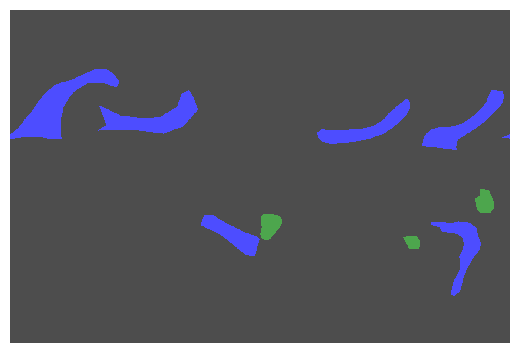

In [51]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt

mask = gt_mask.cpu().numpy().astype(int)

cmap = ListedColormap(['black', 'green', 'blue'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(mask, cmap=cmap, norm=norm, interpolation='nearest', alpha=0.7)
ax.set_axis_off()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.margins(0)
ax.set_position([0, 0, 1, 1])
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

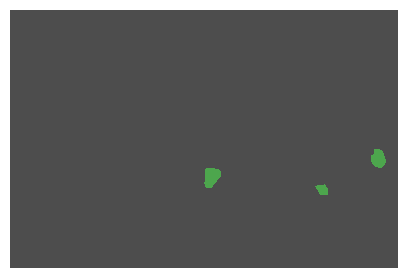

In [39]:
plt.figure(figsize=(5, 4))
plt.imshow(tc_gt_mask, cmap=ListedColormap(['black', 'green']), norm=norm, interpolation='nearest', alpha= 0.7)
plt.axis('off')
plt.show()

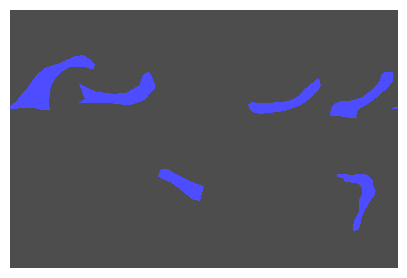

In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(ar_gt_mask, cmap=ListedColormap(['black', 'blue']) interpolation='nearest', alpha= 0.7)
plt.axis('off')
plt.show()

In [58]:
ar_object_masks = batch['ar_object_masks'][0]

ar_object_masks.shape

torch.Size([7, 1, 768, 1152])

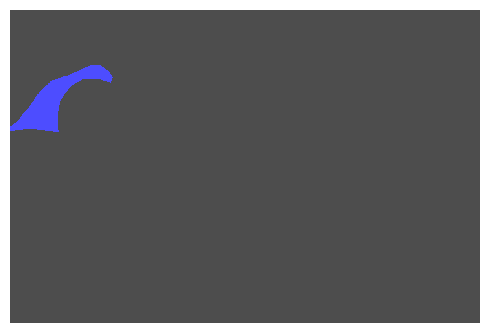

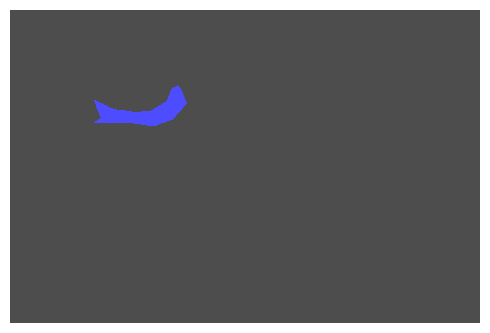

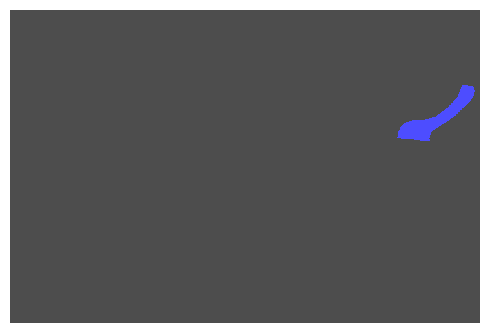

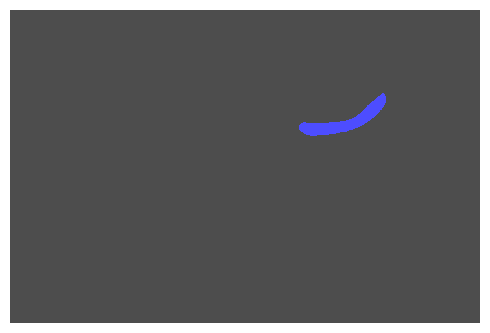

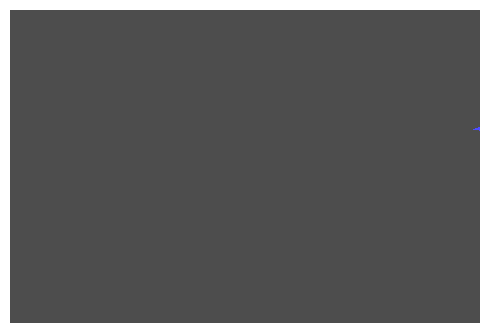

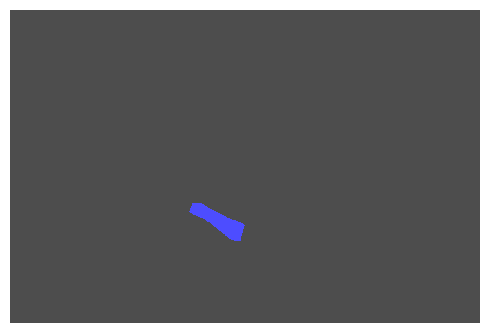

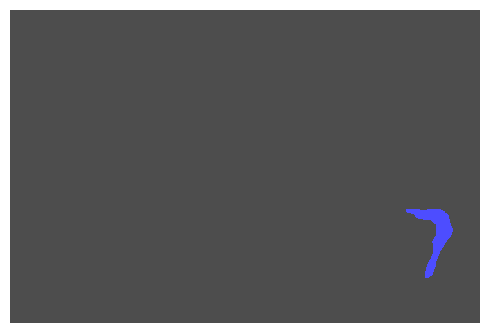

In [63]:
# plot each ar object mask in its own figure (one after another)
try:
    masks = ar_object_masks.cpu().numpy()
except Exception:
    masks = np.array(ar_object_masks)

# collapse channel dim if present: expected (N, 1, H, W) -> (N, H, W)
if masks.ndim == 4 and masks.shape[1] == 1:
    masks = masks[:, 0, ...]
elif masks.ndim == 4 and masks.shape[1] != 1:
    masks = masks.max(axis=1)
elif masks.ndim == 2:
    masks = masks[None, ...]

cmap_ar = ListedColormap(['black', 'blue'])

for i, m in enumerate(masks):
    m2 = (np.squeeze(m) > 0.5).astype(np.uint8)
    plt.figure(figsize=(5, 4))
    plt.imshow(m2, cmap=cmap_ar, interpolation='nearest', alpha=0.7)
    # plt.title(f"mask {i}", fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
